# 4 -- Definición, Entrenamiento y Evaluación del modelo LSTM baseline — Dataset FDIC RIS

Antes de realizar el modelo hibrido, el cual contiene, a parte de las caracteristicas temporales, caracteristicas relacionales, definimos un modelo base simple el cual nos servira como punto de partida ante los resultados que obtendremos, para validar de esta forma la hipotesis central del TFM, la cual establece que si los datos (embeddings) relacionales son un factor determinante o la inclusión de estos en el estudio de quiebras bancarias junto con los datos temporales economicos no suponene una mejora respecto a una vision más conservadora y tradicional.

### Limitación de las Redes Feedforward y Formalización de Redes Recurrentes (RNN)

Las arquitecturas de redes neuronales de alimentación hacia adelante (feedforward) asumen independencia estadística entre las muestras de entrada. Sea una secuencia de observaciones $X = (x_1, x_2, \dots, x_T)$, donde cada $x_t \in \mathbb{R}^{d_{in}}$. Una red feedforward procesa cada $x_t$ de forma aislada, lo que impide la captura de dependencias temporales u ordenamientos secuenciales donde el estado actual condicione los estados futuros ($P(x_t \mid x_{t-1}, x_{t-2}, \dots)$).Las Redes Neuronales Recurrentes (RNN) introducen un mecanismo de persistencia de información mediante un lazo de retroalimentación en la capa oculta. El estado oculto $h_t \in \mathbb{R}^{d_h}$ actúa como un descriptor dinámico de la memoria histórica del sistema, actualizándose recursivamente en cada paso temporal $t$ mediante la siguiente ecuación en diferencias:
$$
h_t = \sigma(W_h h_{t-1} + W_x x_t + b)
$$

Donde $W_h \in \mathbb{R}^{d_h \times d_h}$ es la matriz de pesos de la transición de estado, $W_x \in \mathbb{R}^{d_h \times d_{in}}$ es la matriz de pesos de la entrada, $b \in \mathbb{R}^{d_h}$ es el vector de sesgo y $\sigma$ es una función de activación no lineal (típicamente $\tanh$ o la función sigmoide).

La optimización de una RNN se realiza mediante el algoritmo de Retropropagación a través del Tiempo (Backpropagation Through Time o BPTT). Sea $\mathcal{L}$ la pérdida total de la secuencia. Para calcular el gradiente de la pérdida respecto a la matriz de pesos recurrentes $W_h$, se aplica la regla de la cadena, requiriendo el producto de matrices Jacobianas para evaluar la dependencia de largo alcance entre el estado en el tiempo $t$ y un estado previo en el tiempo $\tau$ (donde $\tau \ll t$):
$$
\frac{\partial h_t}{\partial h_{\tau}} = \prod_{k=\tau+1}^{t} \frac{\partial h_k}{\partial h_{k-1}} = \prod_{k=\tau+1}^{t} \text{diag}\left(\sigma'(a_k)\right) W_h^T
$$

Donde $a_k = W_h h_{k-1} + W_x x_k + b$. Por tanto si el radio espectral de la matriz de pesos $W_h$ es menor que la unidad , rho(W_h) < 1$, y dado que la derivada de las funciones no lineales de activación, como por ejemplo $\tanh$, está acotada en $(0, 1]$, los términos de la multiplicación geométrica convergen exponencialmente a cero a medida que la distancia temporal $t - \tau$ aumenta. Este fenómeno, conocido como el desvanecimiento del gradiente, anula la señal de error para componentes temporales lejanas, limitando la capacidad de la RNN para aprender dependencias de largo plazo. Inversamente, si $\rho(W_h) > 1$, los gradientes crecen exponencialmente, provocando el fenómeno de gradiente explosivo.

### Arquitectura Long Short-Term Memory (LSTM)

Introducida por Hochreiter y Schmidhuber (1997), la arquitectura LSTM resuelve la atenuación del gradiente sustituyendo la unidad recurrente simple por una celda de memoria compleja regulada por compuertas (gates).La celda mantiene dos estados vectoriales concurrentes:

- Estado de Celda ($c_t \in \mathbb{R}^{d_h}$): Representa la memoria intrínseca de largo plazo. Modulado por operaciones aditivas lineales que mitigan la degradación del gradiente.

- Estado Oculto ($h_t \in \mathbb{R}^{d_h}$): Representa la memoria de corto plazo y constituye la salida accesible de la celda en el paso $t$.

Sea $[h_{t-1}, x_t] \in \mathbb{R}^{d_h + d_{in}}$ la concatenación del estado oculto previo y la entrada actual. El flujo de información se gobierna por el siguiente sistema de ecuaciones lineales y no lineales:
$$\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \\
\tilde{c}_t &= \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}$$

Donde $W_f, W_i, W_c, W_o \in \mathbb{R}^{d_h \times (d_h + d_{in})}$, $b_f, b_i, b_c, b_o \in \mathbb{R}^{d_h}$, $\sigma$ es la función sigmoide logística que proyecta al rango abierto $(0, 1)$, $\tanh$ proyecta al rango $(-1, 1)$, y $\odot$ denota el producto de Hadamard (operación elemento a elemento). El mecanismo crítico de la LSTM radica en la actualización del estado de celda: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$. Al calcular la derivada parcial del estado de celda actual respecto al anterior se obtiene:
$$
\frac{\partial c_t}{\partial c_{t-1}} = f_t
$$

Si la compuerta de olvido se activa cerca de la unidad ($f_t \approx 1$), el gradiente del error puede retropropagarse de manera lineal y aditiva directamente a través del tiempo sin sufrir una atenuación exponencial. Esto constituye el denominado Carrusel de Error de Gradiente Constante (Constant Error Carousel).

Las diferentes compuertas poseen una funciónalidad especifica:

- Compuerta de Olvido ($f_t$): Evalúa la relevancia del contexto pasado. Si un elemento $f_{t,j} \to 0$, la información histórica correspondiente en $c_{t-1,j}$ se elimina del vector de memoria por completo.

- Compuerta de Entrada ($i_t$) y Candidato ($\tilde{c}_t$): El término $\tilde{c}_t$ genera nuevas características candidatas escaladas no linealmente. La compuerta $i_t$ actúa como un filtro de cuantificación que determina la magnitud de la incorporación de estas nuevas características al estado de memoria.

- Compuerta de Salida ($o_t$): Filtra la memoria consolidada de la celda ($c_t$) tras pasar por una normalización $\tanh$, abstrayendo únicamente la información pertinente para generar la respuesta externa del modelo $h_t$ en dicho paso temporal.

En el análisis de series temporales de riesgo sistémico o financiero, cada paso temporal $t$ se alimenta con un vector de características proyectadas $x_t = e_{\text{projected}} \in \mathbb{R}^{d_{model}}$, el cual sintetiza la posición contable, métricas de liquidez, solvencia y balance de una entidad bancaria en un trimestre específico.La incorporación de la LSTM en este dominio ofrece ventajas estructurales fundamentadas:

- El uso del filtro estructural via $f_t$ permite discriminar y suprimir variaciones transitorias de alta frecuencia (ruido contable estacional) de las tendencias macroeconómicas o de deterioro latente de largo plazo.

- El modelado no lineal hace que las interacciones complejas entre variables macro (e.g., tasas de interés) y micro (e.g., tasa de morosidad) se aproximanen mediante las composiciones afines de las compuertas.

- Ventanas Temporales Acotadas: Para secuencias de baja frecuencia (v.g., 4 trimestres), la memoria celular estabiliza la representación vectorial del perfil del banco a lo largo del año fiscal completo sin pérdida de resolución temporal.

En nuestro caso, para modelar la dinámica temporal de las entidades financieras, se dispone de secuencias compactas de longitud fija $T=4$, representadas por un tensor de activaciones 

$$
X^{i} = (x_{1}^{(i)}, x_{2}^{(i)}, x_{3}^{(i)}, x_{4}^{(i)})^\top \in \mathbb{R}^{4 \times d}
$$
, donde cada $x_{t}^{(i)}$ codifica las variables macroeconómicas y contables de la entidad $i$ en el trimestre $t$. La naturaleza del problema exige un operador capaz de capturar la dependencia secuencial y la trayectoria evolutiva de los vectores, superando las limitaciones de los enfoques estáticos.La idoneidad de la arquitectura de Memoria a Largo Corto Plazo ($\text{LSTM}$, Long Short-Term Memory) sobre otras topologías secuenciales se fundamenta en las siguientes propiedades estructurales.

A diferencia de los modelos autorregresivos estáticos o de las proyecciones independientes por paso temporal, la $\text{LSTM}$ actúa como un sistema dinámico discreto no lineal parametrizado. El estado oculto final $h_4 \in \mathbb{R}^{h}$ se obtiene mediante la aplicación recursiva de una función de transición $\mathcal{F}$:

$$
h_t = \mathcal{F}(h_{t-1}, x_t; \Theta)
$$

Por expansión recursiva, el vector de características final es una composición no lineal que colapsa toda la historia de la secuencia: $h_4 = \mathcal{F}(\mathcal{F}(\mathcal{F}(\mathcal{F}(h_0, x_1), x_2), x_3), x_4)$.Esta propiedad es crucial desde la perspectiva de la teoría de alerta temprana bancaria (_Early Warning Systems_). Como determinan Cole y Gunther (1995), los procesos de insolvencia y quiebra técnica no se manifiestan como discontinuidades puntuales u observaciones aisladas en un único punto del tiempo $t=4$. Por el contrario, responden a trayectorias estocásticas de deterioro estructural crónico, caracterizadas por la degradación monótona de los ratios de adecuación de capital y la erosión progresiva de la calidad de los activos durante los trimestres $t-3, t-2$ y $t-1$. Una arquitectura carente de memoria inter-temporal realizaría la inferencia exclusivamente sobre el soporte de la distribución marginal de $x_4$, omitiendo los componentes de velocidad y aceleración de los vectores de estado financieros, los cuales albergan la mayor varianza discriminativa para la detección precoz del riesgo.

La compuerta de olvido $f_t \in (0,1)^h$ permite al modelo parametrizar de forma diferenciable la tasa de decaimiento de la información histórica, mientras que la compuerta de entrada $i_t$ modula la inyección de nuevas perturbaciones macroeconómicas.Matemáticamente, la derivada del estado de la celda final respecto a un estado anterior viene dada por la regla de la cadena:

$$
\frac{\partial c_4}{\partial c_t} = \prod_{k=t+1}^4 \frac{\partial c_k}{\partial c_{k-1}} = \prod_{k=t+1}^4 \left( f_k + \text{términos aditivos de las compuertas} \right)
$$

En una $\text{RNN}$ convencional, esta derivada involucra el producto continuado de matrices de pesos $\prod W^\top$, lo que provoca que el gradiente se desvanezca de forma exponencial si el radio espectral de la matriz es inferior a la unidad ($\rho(W) < 1$). Si bien con una longitud de secuencia acotada a $T=4$ el fenómeno del desvanecimiento del gradiente (vanishing gradient) ve mitigado su impacto asintótico, la estructura aditiva de la celda de la $\text{LSTM}$ garantiza que el gradiente fluya uniformemente hacia atrás (backpropagation through time, $\text{BPTT}$) sin sufrir atenuaciones ni explosiones numéricas artificiales induciendo una superficie de pérdida (loss landscape) más suave y propicia para la optimización basada en gradiente estocástico.

In [ ]:
# ============================================================================
# BLOQUE 1 — CARGA Y VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_tab)
# ============================================================================
#
# Modelo: LSTM Baseline (solo datos numéricos / tabulares vía TabPFN)
#
# Objetivo de este bloque: cargar embeddings_desarrollo.parquet, verificar
# su consistencia con el panel etiquetado original, y dejar un DataFrame
# único (emb_dev_labeled) listo para la construcción de secuencias del
# Bloque 2.
#
# NO se toca en ningún momento el bloque de evaluación (2022Q1-2025Q4):
# permanece reservado hasta la evaluación final del modelo ya entrenado.
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ----------- 1.0 REPRODUCIBILIDAD -----------
SEED = 42
np.random.seed(SEED)

# ----------- 1.1 RUTAS -----------
DATA_ROOT = Path("D:/financial_risk_data")
EMBEDDINGS_ROOT = DATA_ROOT / "embeddings"

EMB_DEV_PATH = EMBEDDINGS_ROOT / "emb_dev/embeddings_desarrollo.parquet"
PANEL_LABEL_PATH = DATA_ROOT / "processed" / "panel_tabular_labeled.parquet"


# Carga de ambos embeddings y del panel de etiquetas para google colab
emb_dev     = pd.read_parquet("D:/financial_risk_data/embeddings/emb_dev/embeddings_desarrollo.parquet")
emb_rel     = pd.read_parquet("D:/financial_risk_data/embeddings/emb_rel_dev/erel_desarrollo.parquet")
panel_label = pd.read_parquet("D:/financial_risk_data/processed/panel_tabular_labeled.parquet")

VERBOSE = True

# ----------- 1.2 CARGA -----------
emb_dev = pd.read_parquet(EMB_DEV_PATH)
panel_label = pd.read_parquet(PANEL_LABEL_PATH)

if VERBOSE:
    print(f"emb_dev shape     : {emb_dev.shape}")
    print(f"panel_label shape : {panel_label.shape}")

# ----------- 1.3 NORMALIZACIÓN DE TIPOS -----------
for df in [emb_dev, panel_label]:
    df["CERT"] = df["CERT"].astype(str)
    df["period"] = df["period"].astype(str)

# ----------- 1.4 IDENTIFICAR COLUMNAS DE EMBEDDING -----------
META_DEV = ["CERT", "period"]
cols_emb = [c for c in emb_dev.columns if c not in META_DEV]

assert len(cols_emb) == 192, (
    f"Se esperaban 192 dimensiones de embedding (espacio latente de "
    f"TabPFN v2.6), se encontraron {len(cols_emb)}."
)

# ----------- 1.5 UNIR ETIQUETA failed DESDE panel_tabular_labeled -----------
# Se usa la MISMA fuente de etiqueta que en el T-GCN y el trabajo previo
# del LSTM-AE, para garantizar comparabilidad histórica de los números.
# how='left' + fillna(0): un CERT/period sin entrada en panel_label se
# asume no-quiebra (consistente con el procesamiento ya usado en el
# documento de extracción de TabPFN: panel['failed'].fillna(0).astype(int)).

emb_dev_labeled = emb_dev.merge(
    panel_label[["CERT", "period", "failed"]],
    on=["CERT", "period"],
    how="left",
)
n_sin_etiqueta = emb_dev_labeled["failed"].isna().sum()
emb_dev_labeled["failed"] = emb_dev_labeled["failed"].fillna(0).astype(int)

# ----------- 1.6 VERIFICACIÓN DE INVARIANTES -----------
n_obs = len(emb_dev_labeled)
n_pos = int(emb_dev_labeled["failed"].sum())
n_nan_emb = emb_dev_labeled[cols_emb].isna().sum().sum()
n_periodos = emb_dev_labeled["period"].nunique()
periodos_sorted = sorted(emb_dev_labeled["period"].unique())

assert n_nan_emb == 0, f"NaN en columnas de embedding: {n_nan_emb}"
assert n_periodos == 23, (
    f"Periodos esperados: 23 (2016Q2→2021Q4, 2016Q1 omitido por falta de "
    f"contexto TabPFN), obtenidos: {n_periodos}"
)
assert periodos_sorted[0] == "2016Q2", f"Primer periodo inesperado: {periodos_sorted[0]}"
assert periodos_sorted[-1] == "2021Q4", f"Último periodo inesperado: {periodos_sorted[-1]}"

# Verificación cruzada: el nº de positivos debe ser compatible con los 70
# positivos documentados para el bloque desarrollo completo (2016Q1-2021Q4,
# 24 trimestres). Al faltar 2016Q1 en el embedding, se espera un nº de
# positivos ligeramente MENOR o IGUAL a 70 (los de 2016Q1 no tienen
# embedding y por tanto no pueden entrar en ninguna secuencia).
if VERBOSE:
    print("\n" + "=" * 60)
    print("BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_tab)")
    print("=" * 60)
    print(f"Observaciones totales        : {n_obs:,}")
    print(f"Positivos (failed=1)         : {n_pos}")
    print(f"Tasa de positivos            : {n_pos/n_obs:.6f}")
    print(f"Filas sin match en panel_label (asumidas failed=0) : {n_sin_etiqueta}")
    print(f"Dimensión de embedding        : {len(cols_emb)}")
    print(f"NaN en embeddings             : {n_nan_emb}")
    print(f"Periodos                      : {n_periodos}  ({periodos_sorted[0]} → {periodos_sorted[-1]})")
    print(f"Entidades (CERT) únicas       : {emb_dev_labeled['CERT'].nunique():,}")
    print("=" * 60)
    print(
        "\nNOTA: si n_pos < 70, la diferencia corresponde a positivos de "
        "2016Q1, que no tiene embedding de TabPFN (sin contexto previo) y "
        "por tanto no puede participar en ninguna secuencia de longitud "
        "T=4 cuyo period_end sea posterior a 2016Q1."
    )

emb_dev shape     : (125575, 194)
panel_label shape : (206129, 3)

BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_tab)
Observaciones totales        : 125,575
Positivos (failed=1)         : 63
Tasa de positivos            : 0.000502
Filas sin match en panel_label (asumidas failed=0) : 0
Dimensión de embedding        : 192
NaN en embeddings             : 0
Periodos                      : 23  (2016Q2 → 2021Q4)
Entidades (CERT) únicas       : 6,176

NOTA: si n_pos < 70, la diferencia corresponde a positivos de 2016Q1, que no tiene embedding de TabPFN (sin contexto previo) y por tanto no puede participar en ninguna secuencia de longitud T=4 cuyo period_end sea posterior a 2016Q1.


La red $\text{LSTM}$ no procesa observaciones distribuidas de manera idéntica e independiente, sino trayectorias estocásticas discretas. Sea $\mathcal{E}_i$ la secuencia cronológica indexada de representaciones vectoriales para una entidad financiera $i$, definida como:

$$
\mathcal{E}_i = \left( x_{t\_1}^{(i)}, x_{t\_2}^{(i)}, \dots, x_{t\_K}^{(i)} \right), \quad x_{t\_m}^{(i)} \in \mathbb{R}^d
$$

donde $K$ es el número total de periodos de presencia activa de la entidad en el registro histórico y $t_m \in \mathbb{N}$ denota el índice del trimestre. La extracción de secuencias se ejecuta aplicando una ventana móvil de longitud $T=4$ trimestres con un paso de desplazamiento (stride) unitario sobre el vector histórico de cada entidad financiera individualizada por su código CERT. Dado un banco que mantiene un registro de presencia activa cuantificado en $K$ periodos, el número máximo de secuencias teóricas generadas se define como:

$$
n_{\text{seq}} = \max(0, K - T + 1)
$$

Para una serie temporal de 23 trimestres, la red genera un total de $20$ trayectorias secuenciales superpuestas por institución.


No obstante, debido a las operaciones de reestructuración corporativa, liquidación y fusiones inherentes al sector financiero, el panel de datos es inherentemente incompleto y discontinuo. Para garantizar la validez matemática de los operadores en diferencias temporales implícitos en la $\text{LSTM}$, se define un filtro algebraico de adyacencia cronológica. Una tupla ordenada de índices temporales $\mathcal{T} = (t_1, t_2, t_3, t_4)$ es admisible si y solo si cumple la condición de consecutividad estricta en el grupo aditivo de los enteros:

$$
\Delta t_m = t_{m+1} - t_m = 1, \quad \forall m \in \{1, 2, 3\}
$$

Lo que operacionalmente se evalúa mediante la restricción analítica sobre el operador de diferenciación hacia adelante:

$$
\nabla \mathcal{T} = \mathbb{1}_3
$$

La imposición rigurosa de este criterio impide que el optimizador compute gradientes sobre transiciones de fase ficticias. Si una entidad desaparece temporalmente del panel debido a un proceso de intervención o cese de actividad y reingresa con posterioridad, la concatenación ingenua de sus trimestres introduciría un salto temporal artificial ($\Delta t_m > 1$). Este fenómeno corrompería la métrica del espacio latente al forzar al modelo a aprender una dinámica de continuidad sobre una discontinuidad estructural, sesgando la representación geométrica de lo que la arquitectura define como una trayectoria de evolución normal o patológica.

Sea el panel de datos financieros representado en el espacio latente intermedio por el tensor de orden 3, $X \in \mathbb{R}^{N \times T \times d_{\text{model}}}$, donde $N$ es el número total de trayectorias secuenciales admisibles y $T=4$ la dimensión temporal fija de la ventana. 

> Para cualquier entidad financiera $i$ en un trimestre terminal $t$ (period_end), se define su matriz de trayectoria secuencial $\mathbf{X}_{i, t} \in \mathbb{R}^{4 \times d_{\text{model}}}$ como la tupla temporal de sus vectores de características latentes:

$$
\mathbf{X}_{i, t} = \begin{pmatrix} 
e_{\text{tab}}(t-3)^\top \\ 
e_{\text{tab}}(t-2)^\top \\ 
e_{\text{tab}}(t-1)^\top \\ 
e_{\text{tab}}(t)^\top 
\end{pmatrix}
$$

La existencia matemática de la matriz $\mathbf{X}_{i, t}$ en el conjunto de datos está estrictamente supeditada al cumplimiento simultáneo de dos restricciones operacionales:

- Consecutividad cronológica estricta: $\nabla \mathcal{T} = \mathbb{1}_{3}$, para $\mathcal{T} = (t-3, t-2, t-1, t)$.
- Cota de profundidad temporal inferior: $t - 3 \ge T_{\text{start}}$, donde $T_{\text{start}} = 2016\text{Q}2$ (frontera de contexto impuesta por el codificador $\text{TabPFN}$).

Sea $Y_{i, \tau} \in \{0, 1\}$ la variable aleatoria observable que registra el estado de insolvencia efectiva de la entidad $i$ en el trimestre $\tau$, donde la condición $Y_{i, \tau} = 1$ denota la etiqueta binaria failed = 1 y $Y_{i, \tau} = 0$ denota solvencia. La asignación de la etiqueta secuencial se realiza mediante el operador de proyección terminal $\mathcal{P}_{\text{end}}(\mathbf{X}_{i, t}) \triangleq Y_{i, t}$.

> Se define una __Secuencia Válida o Sana__, indexada por la variable indicadora $\tilde{Y}_{i, t} = 0$, como aquella matriz de trayectoria $\mathbf{X}_{i, t}$ que cumple con las restricciones de consecutividad y profundidad temporal y cuyo operador de proyección sobre el periodo de cierre es nulo:
> $$\tilde{Y}_{i, t} = 0 \iff \mathcal{P}_{\text{end}}(\mathbf{X}_{i, t}) = 0 \implies Y_{i, t} = 0$$

Esta definición establece que el estado de la entidad en el horizonte terminal $t$ es estrictamente solvente.Es importante destacar que esta formulación no restringe los estados intermedios del pasado de la ventana ($\tau \in \{t-3, t-2, t-1\}$). Una trayectoria donde una entidad haya registrado una perturbación o insolvencia transitoria previa (v.g., $Y_{i, t-2} = 1$) pero que en el trimestre de corte se encuentre operativa y saneada ($Y_{i, t} = 0$), se clasifica formalmente como una secuencia sana para ese horizonte predictivo concreto.En el conjunto de validación ($\mathcal{D}_{\text{val}}$), bajo la frontera $N_{\text{val\_periods}} = 8$, se localizan $19\,904$ secuencias que satisfacen de forma pura esta condición.

>Se define una Secuencia Anómala o de Fallo, indexada por la variable indicadora $\tilde{Y}_{i, t} = 1$, como aquella matriz de trayectoria $\mathbf{X}_{i, t}$ que cumple con las restricciones de consecutividad y profundidad temporal y cuyo operador de proyección sobre el periodo de cierre es unitario:
>$$\tilde{Y}_{i, t} = 1 \iff \mathcal{P}_{\text{end}}(\mathbf{X}_{i, t}) = 1 \implies Y_{i, t} = 1$$

Esta definición establece de forma unívoca que la entidad financiera se encuentra en estado de quiebra efectiva (failed = 1) exactamente en el trimestre terminal $t$ (period_end).El cardinal de este conjunto representa la cantidad de snapshots evolutivos o ventanas dinámicas de fallo utilizables, no el número de bancos físicos. Un mismo banco con un estado de insolvencia prolongado en el tiempo solo generará una secuencia anómala si dicho trimestre constituye el vector de cierre de una ventana de contexto de longitud $T=4$ con tres trimestres de historia previa válida en el panel.

In [4]:
# ============================================================================
# BLOQUE 2a-bis — VERIFICACIÓN: positivos EN SECUENCIA por frontera candidata
# ============================================================================
#
# Corrige el diagnóstico original del Bloque 2a, que contaba positivos
# sobre OBSERVACIONES individuales (proxy que sobreestima la señal
# disponible, especialmente para quiebras tempranas sin historia previa
# suficiente para formar una ventana T=4 válida).
#
# Aquí se cuenta sobre SECUENCIAS reales ya construidas en el Bloque 2b
# (sequences_train + sequences_val, antes de aplicar la frontera N_VAL=8),
# para confirmar si existe alguna frontera N_VAL < 8 que ya produzca
# secuencias-positivo en val.
#
# Requiere haber ejecutado antes una construcción de secuencias SIN
# frontera (o reconstruir con val_periods=todos los periodos) para tener
# el universo completo de secuencias con su period_end, y clasificarlas
# después según cada frontera candidata.
# ============================================================================

# ----------- 2b.1 MAPA DE PERIODOS -----------
all_periods_sorted = sorted(emb_dev_labeled["period"].unique())
period_to_idx = {p: i for i, p in enumerate(all_periods_sorted)}

emb_dev_labeled["period_idx"] = emb_dev_labeled["period"].map(period_to_idx)
emb_dev_labeled = emb_dev_labeled.sort_values(["CERT", "period_idx"]).reset_index(drop=True)

# ----------- 2b.3 CONSTRUCCIÓN DE VENTANAS -----------

def build_sequences_supervised(
    df,
    cols_emb,
    period_to_idx,
    window_len,
    stride,
    val_periods,
):
    """
    Construye ventanas deslizantes por entidad (CERT), con `failed` en
    period_end como TARGET supervisado (no metadato).

    Idéntica en mecánica a la función build_sequences del pipeline
    anterior (Bloque 2, LSTM-AE): consecutividad estricta, agrupación
    por CERT, target en el último paso de la ventana. La diferencia es
    semántica/de contrato de datos: aquí 'failed' es el target real de
    la loss, no metadato informativo aparte (is_anomalous).
    """
    sequences_train = []
    sequences_val = []
    n_skipped_gaps = 0

    for cert, group in df.groupby("CERT", sort=False):
        group = group.sort_values("period_idx").reset_index(drop=True)
        n_obs = len(group)

        if n_obs < window_len:
            continue

        X_banco = group[cols_emb].values
        periods = group["period"].values
        period_idxs = group["period_idx"].values
        failed_vals = group["failed"].values

        for start in range(0, n_obs - window_len + 1, stride):
            end = start + window_len

            if not np.all(np.diff(period_idxs[start:end]) == 1):
                n_skipped_gaps += 1
                continue

            period_end = periods[end - 1]
            target = int(failed_vals[end - 1])  # TARGET supervisado, no metadato

            seq = {
                "X": X_banco[start:end],       # (window_len, d_in)
                "CERT": cert,
                "period_end": period_end,
                "failed": target,
            }

            if period_end in val_periods:
                sequences_val.append(seq)
            else:
                sequences_train.append(seq)

    if VERBOSE:
        print(f"\nVentanas descartadas por huecos: {n_skipped_gaps}")

    return sequences_train, sequences_val


# Reconstruir el universo COMPLETO de secuencias sin aplicar ninguna
# frontera train/val (val_periods vacío => todo cae en "train" de forma
# nominal, lo que aquí se usa solo como contenedor único de secuencias).
sequences_all, _ = build_sequences_supervised(
    df=emb_dev_labeled,
    cols_emb=cols_emb,
    period_to_idx=period_to_idx,
    window_len=4,
    stride=1,
    val_periods=set(),  # ninguna secuencia se desvía a val aquí
)


print("=" * 70)
print("POSITIVOS EN SECUENCIA (real) POR FRONTERA CANDIDATA")
print("=" * 70)
print(f"{'N_VAL':>6} | {'val_periods':35s} | {'seq_pos_train':>13} | {'seq_pos_val':>11}")
print("-" * 75)

for n_val in range(2, 9):
    val_periods_candidato = set(all_periods_sorted[-n_val:])

    pos_train_real = sum(
        s["failed"] for s in sequences_all if s["period_end"] not in val_periods_candidato
    )
    pos_val_real = sum(
        s["failed"] for s in sequences_all if s["period_end"] in val_periods_candidato
    )

    rango_val = f"{sorted(val_periods_candidato)[0]}→{sorted(val_periods_candidato)[-1]}"
    print(f"{n_val:>6} | {rango_val:35s} | {pos_train_real:>13} | {pos_val_real:>11}")




Ventanas descartadas por huecos: 0
POSITIVOS EN SECUENCIA (real) POR FRONTERA CANDIDATA
 N_VAL | val_periods                         | seq_pos_train | seq_pos_val
---------------------------------------------------------------------------
     2 | 2021Q3→2021Q4                       |            41 |           0
     3 | 2021Q2→2021Q4                       |            41 |           0
     4 | 2021Q1→2021Q4                       |            41 |           0
     5 | 2020Q4→2021Q4                       |            41 |           0
     6 | 2020Q3→2021Q4                       |            39 |           2
     7 | 2020Q2→2021Q4                       |            37 |           4
     8 | 2020Q1→2021Q4                       |            34 |           7


Al evaluar el impacto de la longitud del periodo de validación ($N_{\text{val\_periods}}$) directamente sobre el espacio de trayectorias admisibles $\mathcal{S}$ en lugar de sobre la matriz de observaciones, el dilema de partición se redefine por las siguientes caracteristicas:

Si tomamos un periodo de validación de 4 trimestres, no tenemos secuencias anomalas en nuestro conjunto de validación haciendo que el early stopping opere a ciegas. Con un periodo de 6 trimestres ahora si tendriamos secuencias anomalas en validación pero al ser tan pocas tendriamos una alta varianza en el estimador de la pérdida debido al tamaño muestral crítico ($n=2$). El caso mas optimo es tomar 8 trimestres en validación lo cual deja una señal discriminativa mínima y estable para el cálculo de la entropía cruzada fuera de muestra.

In [ ]:
# ============================================================================
# BLOQUE 2   — CONSTRUCCIÓN DE SECUENCIAS TEMPORALES (target supervisado)
# ============================================================================
#
# Ventana deslizante T=4, stride=1, consecutividad estricta — misma lógica
# ya validada en el Bloque 2 del pipeline anterior (LSTM-AE).
#
# Diferencia respecto al diseño anterior: `failed` en period_end es ahora
# el TARGET de la función de pérdida (BCEWithLogitsLoss), no un metadato
# informativo. La frontera train/val se fija en N_VAL_PERIODS=8
# (2020Q1→2021Q4), justificada empíricamente en el Bloque 2a: deja 7
# positivos en val frente a 2 con la frontera genérica anterior (N=4),
# dando una señal de validación más estable para early stopping vía AUC-PR.
# ============================================================================

import torch
from torch.utils.data import Dataset

WINDOW_LENGTH = 4
STRIDE = 1
N_VAL_PERIODS = 8  # fijado tras diagnóstico del Bloque 2a

# ----------- 2b.1 MAPA DE PERIODOS -----------
all_periods_sorted = sorted(emb_dev_labeled["period"].unique())
period_to_idx = {p: i for i, p in enumerate(all_periods_sorted)}

emb_dev_labeled["period_idx"] = emb_dev_labeled["period"].map(period_to_idx)
emb_dev_labeled = emb_dev_labeled.sort_values(["CERT", "period_idx"]).reset_index(drop=True)

# ----------- 2b.2 FRONTERA TRAIN/VAL -----------
val_periods = set(all_periods_sorted[-N_VAL_PERIODS:])
train_periods = set(all_periods_sorted[:-N_VAL_PERIODS])

if VERBOSE:
    print(f"Frontera train/val (N_VAL_PERIODS={N_VAL_PERIODS}):")
    print(f"  Train period_end hasta : {max(train_periods)}")
    print(f"  Val period_end desde   : {min(val_periods)}")
    print(f"  Periodos en val        : {sorted(val_periods)}")

# ----------- 2b.3 CONSTRUCCIÓN DE VENTANAS -----------

def build_sequences_supervised(
    df,
    cols_emb,
    period_to_idx,
    window_len,
    stride,
    val_periods,
):
    """
    Construye ventanas deslizantes por entidad (CERT), con `failed` en
    period_end como TARGET supervisado (no metadato).

    Idéntica en mecánica a la función build_sequences del pipeline
    anterior (Bloque 2, LSTM-AE): consecutividad estricta, agrupación
    por CERT, target en el último paso de la ventana. La diferencia es
    semántica/de contrato de datos: aquí 'failed' es el target real de
    la loss, no metadato informativo aparte (is_anomalous).
    """
    sequences_train = []
    sequences_val = []
    n_skipped_gaps = 0

    for cert, group in df.groupby("CERT", sort=False):
        group = group.sort_values("period_idx").reset_index(drop=True)
        n_obs = len(group)

        if n_obs < window_len:
            continue

        X_banco = group[cols_emb].values
        periods = group["period"].values
        period_idxs = group["period_idx"].values
        failed_vals = group["failed"].values

        for start in range(0, n_obs - window_len + 1, stride):
            end = start + window_len

            if not np.all(np.diff(period_idxs[start:end]) == 1):
                n_skipped_gaps += 1
                continue

            period_end = periods[end - 1]
            target = int(failed_vals[end - 1])  # TARGET supervisado, no metadato

            seq = {
                "X": X_banco[start:end],       # (window_len, d_in)
                "CERT": cert,
                "period_end": period_end,
                "failed": target,
            }

            if period_end in val_periods:
                sequences_val.append(seq)
            else:
                sequences_train.append(seq)

    if VERBOSE:
        print(f"\nVentanas descartadas por huecos: {n_skipped_gaps}")

    return sequences_train, sequences_val


sequences_train, sequences_val = build_sequences_supervised(
    df=emb_dev_labeled,
    cols_emb=cols_emb,
    period_to_idx=period_to_idx,
    window_len=WINDOW_LENGTH,
    stride=STRIDE,
    val_periods=val_periods,
)

# ----------- 2b.4 VERIFICACIÓN DE INVARIANTES -----------
n_train = len(sequences_train)
n_val = len(sequences_val)
n_pos_train = sum(s["failed"] for s in sequences_train)
n_pos_val = sum(s["failed"] for s in sequences_val)

assert {s["period_end"] for s in sequences_train}.isdisjoint(val_periods), (
    "Contaminación temporal: period_ends de train solapan con val_periods"
)
assert sequences_train[0]["X"].shape == (WINDOW_LENGTH, len(cols_emb)), (
    f"Shape esperado ({WINDOW_LENGTH}, {len(cols_emb)}), "
    f"obtenido {sequences_train[0]['X'].shape}"
)
# A diferencia del LSTM-AE: aquí SÍ esperamos positivos en val. Si esto
# fallara, la frontera fijada en el Bloque 2a no estaría siendo respetada.
assert n_pos_val > 0, (
    "Val no contiene positivos pese a la frontera N_VAL_PERIODS=8. "
    "Revisar consistencia con el diagnóstico del Bloque 2a."
)

if VERBOSE:
    print("\n" + "=" * 60)
    print("BLOQUE — VERIFICACIÓN DE SECUENCIAS (target supervisado)")
    print("=" * 60)
    print(f"Secuencias train         : {n_train:,}")
    print(f"  Positivos en train     : {n_pos_train}  (tasa: {n_pos_train/n_train:.6f})")
    print(f"Secuencias val           : {n_val:,}")
    print(f"  Positivos en val       : {n_pos_val}  (tasa: {n_pos_val/n_val:.6f})")
    print(f"Total secuencias         : {n_train + n_val:,}")
    print(f"Shape por secuencia      : {sequences_train[0]['X'].shape}")
    print("=" * 60)

# ----------- 2b.5 DATASET PYTORCH -----------

class SupervisedSequenceDataset(Dataset):
    """
    Dataset PyTorch sobre ventanas temporales con target supervisado.

    A diferencia del SequenceDataset del LSTM-AE (donde is_anomalous era
    metadato), aquí 'failed' es el target real que se compara contra
    los logits del modelo en BCEWithLogitsLoss. CERT y period_end se
    mantienen como metadato adicional, útiles para trazabilidad,
    evaluación agrupada por entidad, y explicabilidad posterior.
    """

    def __init__(self, sequences: list) -> None:
        self.sequences = sequences

    def __len__(self) -> int:
        return len(self.sequences)

    def __getitem__(self, idx: int) -> dict:
        seq = self.sequences[idx]
        return {
            "X": torch.tensor(seq["X"], dtype=torch.float32),
            "failed": torch.tensor(seq["failed"], dtype=torch.float32),  # float: BCEWithLogitsLoss lo espera así
            "CERT": seq["CERT"],
            "period_end": seq["period_end"],
        }


# ----------- 2b.6 pos_weight SOBRE TRAIN -----------
# Calculado exclusivamente sobre el split de train interno, replicando
# el mismo procedimiento ya validado en el T-GCN: pos_weight es un
# estadístico del conjunto de entrenamiento, nunca de validación ni del
# bloque de evaluación final.

n_neg_train = n_train - n_pos_train
pos_weight_raw = n_neg_train / n_pos_train

if VERBOSE:
    print(f"\npos_weight (ratio bruto neg/pos en train): {pos_weight_raw:.2f}")


Frontera train/val (N_VAL_PERIODS=8):
  Train period_end hasta : 2019Q4
  Val period_end desde   : 2020Q1
  Periodos en val        : ['2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4']

Ventanas descartadas por huecos: 0

BLOQUE — VERIFICACIÓN DE SECUENCIAS (target supervisado)
Secuencias train         : 66,922
  Positivos en train     : 34  (tasa: 0.000508)
Secuencias val           : 40,355
  Positivos en val       : 7  (tasa: 0.000173)
Total secuencias         : 107,277
Shape por secuencia      : (4, 192)

pos_weight (ratio bruto neg/pos en train): 1967.29


Tubería de Datos: Diferenciación entre Estructura de Datos (Dataset) e Iteración Estocástica (DataLoader)

Para comprender el flujo de alimentación del modelo predictivo, es imperativo distinguir entre la definición abstracta de una muestra y la estrategia de muestreo estadístico utilizada durante la optimización. La tubería de datos se divide en dos capas funcionales independientes y complementarias:
```python
+--------------------------------------------+
|         MUESTRAS INDIVIDUALES              |
|  sequences_train / sequences_val (Listas)  |
+--------------------------------------------+
                      |
                      v
+--------------------------------------------+
|        1. CAPA DE DEFINICIÓN (Dataset)     |
|   - Envuelve secuencias individuales.      |
|   - Acceso indexado: __getitem__(i)        |
|   - Retorna: X (4, 192) y failed (escalar) |
+--------------------------------------------+
                      |
                      v
+--------------------------------------------+
|      2. CAPA DE ALIMENTACIÓN (DataLoader)  |
|   - Controla el orden (Shuffle / Sampler). |
|   - Agrupa en lotes (Batch Size = 256).    |
|   - Apila tensores (Collate): (256, 4, 192)|
+--------------------------------------------+
``` 

1. La Capa de Definición Estática (Dataset): La clase `SupervisedSequenceDataset` actúa como un contenedor estático cuyo único propósito es estructurar y delimitar la unidad mínima de información. Responde a la pregunta: ¿Qué es una observación para el modelo? Al encapsular las listas de secuencias ya verificadas (respetando la frontera temporal cronológica), este objeto proporciona una interfaz estandarizada mediante los métodos matemáticos de longitud (__len__) y acceso indexado (__getitem__). Al invocar un índice individual, el contenedor expone exclusivamente los tensores de una única entidad: una matriz de características latentes $X \in \mathbb{R}^{4 \times 192}$ y su correspondiente etiqueta escalar binaria $\tilde{Y} \in \{0, 1\}$. En esta capa, los datos permanecen aislados e inmóviles; el Dataset no posee noción de lotes, orden de recorrido ni paralelismo computacional.

2. La Capa de Dinámica Estocástica (`DataLoader`): El operador `DataLoader` constituye la capa de abstracción encargada de orquestar la interacción entre el contenedor estático y el algoritmo de optimización. Responde a la pregunta: ¿Cómo debe el optimizador consumir las observaciones? Sus responsabilidades técnicas e implicaciones estadísticas se agrupan en tres ejes:

- Contracción Dimensional (Collating): Un Dataset solo extrae diccionarios individuales. El `DataLoader` recupera de forma iterativa un número de muestras equivalente al tamaño del lote (batch_size = 256) y ejecuta una operación de apilado (stacking). Transforma variables discretas distribuidas en memoria en un único tensor unificado apto para el procesamiento en paralelo en la GPU, con una signatura matricial de $X_{\text{batch}} \in \mathbb{R}^{256 \times 4 \times 192}$.

- Composición Estadística del Lote: La selección de los hiperparámetros de esta capa altera directamente la distribución empírica que percibe el optimizador en cada iteración del descenso de gradiente. Bajo un muestreo aleatorio estándar (shuffle=True), cada lote hereda la prevalencia natural de la población de entrenamiento ($34$ secuencias anómalas sobre $66\,922$ totales, equivalente a una tasa del $0.0508\%$). Esto determina de forma matemática el número esperado de positivos por lote:

$$
\mathbb{E}[\text{Positivos por lote}] = 256 \times 0.000508 \approx 0.13
$$
Esto implica que la inmensa mayoría de los lotes carecerán de señal de fallo.

- Flexibilidad en la Frontera de Decisión: Si se optara por modificar la estrategia sustituyendo el muestreo uniforme por un muestreo ponderado (`WeightedRandomSampler`), la tasa de positivos por lote se alteraría dinámicamente (por ejemplo, forzando un equilibrio del $50\%$ de positivos en cada batch) sin necesidad de modificar, duplicar ni alterar una sola secuencia física del Dataset.Por consiguiente, la configuración del DataLoader no representa un detalle mecánico trivial de la implementación de software, sino la capa de diseño crítico donde se gobierna la topología de la superficie de pérdida y la estabilidad del flujo de gradientes que guiarán el entrenamiento de la red recurrente.

In [8]:
from torch.utils.data import DataLoader
import torch

# ========== DATALOADER CONSTRUCTION ==========

# Datasets ya construidos en el notebook anterior
dataset_train = SupervisedSequenceDataset(sequences_train)
dataset_val = SupervisedSequenceDataset(sequences_val)

# Hiperparámetros de DataLoader
BATCH_SIZE = 256  # Justificado: E[pos/batch]=0.13, pos_weight=1966 compensa magnitud
SHUFFLE_TRAIN = True  # Shuffle simple, no WeightedRandomSampler
PIN_MEMORY = torch.cuda.is_available() # GPU pinning si disponible
NUM_WORKERS = 0  # Cambiar a 2-4 en producción si data loading es bottleneck


dataloader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE_TRAIN,
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False  # Mantener último batch aunque sea < 256
)

dataloader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,  # Validación sin permutación
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False
)

# ========== DIAGNÓSTICO DE BATCHES ==========

print("=" * 70)
print("DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES")
print("=" * 70)

# Inspeccionar distribución de positivos en el primer epoch
pos_per_batch_train = []
for batch_idx, batch in enumerate(dataloader_train):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_train.append(n_pos_batch)

pos_per_batch_train = torch.tensor(pos_per_batch_train, dtype=torch.float32)

print(f"\nTRAIN (shuffle=True, batch_size={BATCH_SIZE}):")
print(f"  Total batches            : {len(pos_per_batch_train)}")
print(f"  Batches sin positivos    : {(pos_per_batch_train == 0).sum().item()} "
      f"({100*(pos_per_batch_train == 0).sum().item()/len(pos_per_batch_train):.1f}%)")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_train > 0).sum().item()} "
      f"({100*(pos_per_batch_train > 0).sum().item()/len(pos_per_batch_train):.1f}%)")
print(f"  E[positivos/batch]       : {pos_per_batch_train.mean().item():.3f}")
print(f"  σ[positivos/batch]       : {pos_per_batch_train.std().item():.3f}")
print(f"  Max positivos en batch   : {pos_per_batch_train.max().item():.0f}")

print(f"\nVAL (shuffle=False, batch_size={BATCH_SIZE}):")
pos_per_batch_val = []
for batch_idx, batch in enumerate(dataloader_val):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_val.append(n_pos_batch)

pos_per_batch_val = torch.tensor(pos_per_batch_val, dtype=torch.float32)
print(f"  Total batches            : {len(pos_per_batch_val)}")
print(f"  Batches sin positivos    : {(pos_per_batch_val == 0).sum().item()}")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_val > 0).sum().item()}")
print(f"  E[positivos/batch]       : {pos_per_batch_val.mean().item():.3f}")

print("\n" + "=" * 70)
print(f"pos_weight (a usar en BCEWithLogitsLoss) : {pos_weight_raw:.2f}")
print(f"Justificación: cada positivo pesa {pos_weight_raw:.0f}x un negativo")
print("=" * 70)

DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES

TRAIN (shuffle=True, batch_size=256):
  Total batches            : 262
  Batches sin positivos    : 229 (87.4%)
  Batches con ≥1 positivo  : 33 (12.6%)
  E[positivos/batch]       : 0.130
  σ[positivos/batch]       : 0.348
  Max positivos en batch   : 2

VAL (shuffle=False, batch_size=256):
  Total batches            : 158
  Batches sin positivos    : 155
  Batches con ≥1 positivo  : 3
  E[positivos/batch]       : 0.044

pos_weight (a usar en BCEWithLogitsLoss) : 1967.29
Justificación: cada positivo pesa 1967x un negativo


El análisis empírico de las distribuciones de los minilotes para los conjuntos de entrenamiento ($\mathcal{D}_{\text{train}}$) y validación ($\mathcal{D}_{\text{val}}$) expone las restricciones impuestas por el desequilibrio extremo de clases sobre el operador de descenso de gradiente: 

1. Modelado Estocástico del Conjunto de Entrenamiento mediante una Distribución de Poisson: Sea el subconjunto de entrenamiento $\mathcal{D}_{\text{train}}$ con un cardinal total de $N_{\text{train}} = 66\,922$ trayectorias, de las cuales únicamente $N_{\text{train}}^{+} = 34$ corresponden a secuencias anómalas, definiendo una probabilidad empírica de Bernoulli de $\mathbb{P}(Y = 1) = p = 0.000508$. Al configurar un operador de muestreo aleatorio uniforme con reemplazo simulado mediante permutación (shuffle=True) y un tamaño de lote $B = 256$, la variable aleatoria $K$, que contabiliza el número de muestras positivas contenidas en un minilote, se modela asintóticamente mediante una distribución de Poisson, dado que $B \to \infty$, $p \to 0$ y el parámetro de intensidad $\lambda$ permanece acotado:
$$
\lambda = B \cdot p = 256 \times \frac{34}{66\,922} \approx 0.1301
$$

Bajo la hipótesis nula de independencia pura, la probabilidad de que un minilote no contenga ninguna señal discriminativa de fallo viene dada por:

$$
\mathbb{P}(K = 0) = \frac{\lambda^0 e^{-\lambda}}{0!} = e^{-0.1301} \approx 87.80\%
$$

El valor empírico registrado del $87.4\%$ (229 de 262 lotes) exhibe una convergencia robusta con el límite teórico. La discrepancia marginal de $\Delta = 0.4\%$ se justifica analíticamente por las propiedades algebraicas del pipeline de datos:Naturaleza del Muestreo: El operador DataLoader ejecuta un muestreo sin reemplazo sobre el soporte del conjunto indexado durante el transcurso de una misma época (mutando la distribución hipergeométrica subyacente en cada paso).Truncamiento del Lote Terminal: El residuo de la división entera $\mathcal{R} = N_{\text{train}} \pmod B = 66\,922 \pmod{256} = 106$ define un lote residual final con un tamaño efectivo sustancialmente menor ($B_{\text{residual}} = 106$), contrayendo localmente el parámetro de intensidad a $\lambda_{\text{residual}} = 106 \times p \approx 0.0538$, lo que altera de forma determinista la probabilidad agregada del fin de época.Síncronamente, la varianza del proceso cumple con la consistencia paramétrica de Poisson, donde la desviación estándar teórica $\sigma = \sqrt{\lambda} = \sqrt{0.1301} \approx 0.3607$ converge con el estimador empírico del lote ($\sigma_{\text{emp}} = 0.348$).

2. Naturaleza Determinista del Bloque de Validación: En el subconjunto de validación $\mathcal{D}_{\text{val}}$, la evaluación se rige por la restricción secuencial estricta shuffle=False para garantizar la reproducibilidad métrica inter-operación. En consecuencia, la distribución de los 7 positivos sobre los 158 lotes totales no responde a una variable aleatoria de Poisson, sino a una función indicadora determinista dependiente de la ordenación de la base de datos (indexada secuencialmente por el horizonte temporal de cierre period_end y el identificador de la entidad).Aunque el ratio medio nominal coincide numéricamente con el momento de primer orden $\lambda_{\text{val}} = 256 \times (7 / 40355) \approx 0.0444$, las observaciones positivas están concentradas en coordenadas fijas del tensor de datos. Esto invalida metodológicamente el cálculo de promedios batch a batch sobre validación; cualquier funcional de pérdida o métrica de rendimiento fuera de muestra debe computarse mediante una agregación distributiva sobre el split completo antes de la evaluación del gradiente macro.

La interacción entre la baja densidad de positivos por lote y el factor de regularización de la pérdida introduce un riesgo crítico de divergencia numérica. Para compensar la prevalencia asimétrica, la función de pérdida $\text{BCEWithLogitsLoss}$ parametriza un ponderador escalar inverso para la clase minoritaria:

$$
\text{pos\_weight} = \frac{N_{\text{train}} - N_{\text{train}}^{+}}{N_{\text{train}}^{+}} = \frac{66\,922 - 34}{34} \approx 1967.29
$$

Esta asimetría impone una distribución bimodal sobre la norma euclídea del gradiente del modelo, $\|\mathbf{g}\|_2$, a lo largo de las iteraciones de una misma época:
- Fase Estacionaria de Conducción (87.4% de los pasos): Lotes exentos de anomalías ($K=0$). El gradiente evalúa exclusivamente el término de la clase mayoritaria ($y_i = 0$), induciendo actualizaciones suaves y continuas sobre la superficie de pérdida que estabilizan la representación de la normalidad sistémica.

- Fase de Impulso de Cresta (12.6% de los pasos): Lotes con presencia de anomalías ($K \ge 1$). La contribución de la muestra positiva al gradiente es multiplicada linealmente por $\text{pos\_weight} \approx 1967.29$. Esto genera picos de gradiente desproporcionados con una periodicidad media de un impacto cada $\approx 7.9$ lotes.

Dada una arquitectura recurrente $\text{LSTM}$ cuyo espacio de estados ocultos es compacto ($d_{\text{hidden}} \in [16, 48]$), la inyección sin filtrar de estos impulsos de gradiente induce un riesgo inminente de explosión del gradiente e inestabilidad estocástica, deformando la geometría de la frontera de decisión.Se justifica así, de forma matemática y estructural, la incorporación obligatoria de un operador de truncamiento o gradient clipping en la norma del gradiente:

$$
\mathbf{g} \leftarrow \min\left(1.0, \frac{\theta}{\|\mathbf{g}\|_2}\right) \mathbf{g}
$$

donde el umbral de saturación $\theta$ actúa como un hiperparámetro de regularización indispensable para acotar la energía de los picos inducidos por el estimador de la clase minoritaria, preservando la consistencia algebraica de las matrices de pesos de la red recurrente.

Una vez ya hemos definido el modelo LSTM baseline,

Antes de formalizar la implementación algorítmica del bucle de entrenamiento para la red recurrente baseline, es imperativo establecer los fundamentos teóricos que gobiernan la selección del modelo, la calibración de la pérdida y la estabilidad del gradiente.

1. Invarianza Métrica y Criterio de Parada Temprana (Early Stopping): En escenarios caracterizados por una prevalencia marginal de la clase anómala ($\delta \approx 0.05\%$), las métricas tradicionales basadas en la matriz de confusión clásica inducen un sesgo de evaluación crítico. La exactitud global ($\text{Accuracy}$), definida como:

$$
\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}
$$
carece de utilidad analítica; un clasificador trivial uniformemente sesgado hacia la clase mayoritaria ($\hat{y} = 0, \forall x$) registraría una exactitud de $\text{Acc}_{\text{train}} = 99.949\%$ y $\text{Acc}_{\text{val}} = 99.983\%$. Asimismo, el área bajo la curva de características operativas del receptor ($\text{AUC-ROC}$) resulta insuficiente como estimador único de convergencia. El cálculo de la tasa de falsos positivos ($\text{FPR}$), que constituye el eje de abscisas de dicha función:

$$
\text{FPR} = \frac{\text{FP}}{\text{TN} + \text{FP}}
$$

está asintóticamente dominado por el cardinal del soporte negativo ($\text{TN} \to \infty$). Como demuestran Saito y Rehmsmeier (2015), este fenómeno provoca que la curva $\text{ROC}$ permanezca insensible ante incrementos sustanciales en el volumen absoluto de falsos positivos ($\text{FP}$), ofreciendo una percepción optimista y distorsionada del poder discriminativo del modelo cuando la clase de interés es infrecuente.

Consecuentemente, se establece el área bajo la curva Precisión-Recuperación ($\text{AUC-PR}$) como el funcional métrico primario para la selección del estado óptimo de los pesos y como criterio de parada temprana (early stopping). Al mapear directamente la precisión:

$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
$$

frente a la exhaustividad o recall, la métrica aísla el efecto del crecimiento exponencial de los falsos positivos en el denominador, forzando al optimizador a maximizar la densidad del margen de separación sobre la vecindad de la clase minoritaria. Esta elección, además, preserva la consistencia metodológica inter-componente del pipeline al alinearse con la métrica de validación empleada en la arquitectura de grafos espaciotemporales ($\text{T-GCN}$).

La inyección del inverso de la razón de prevalencia cruda como ponderador en la función de pérdida de entropía cruzada binaria ($\text{BCEWithLogitsLoss}$), $\omega_{\text{raw}} = 1967.29$, introduce un riesgo de sobrecorrección geométrica. Un peso hiper-asimétrico penaliza los falsos negativos de forma tan drástica que fuerza al hiperplano de decisión a expandir excesivamente su región de aceptación positiva. Esto provoca que el modelo clasifique muestras limítrofes como fallidas, degradando monótonamente la precisión global del sistema.Para mitigar este comportamiento, se parametriza un factor de atenuación u homografía de escala, $pw\_factor \in (0, 1]$, tal que el ponderador efectivo utilizado por el optimizador se define como:

$$
\omega_{\text{efectivo}} = pw\_factor \times \omega_{\text{raw}}
$$

La inclusión de $pw\_factor$ como un hiperparámetro continuo dentro del espacio de búsqueda bayesiana de Optuna permite al sistema aprender el compromiso óptimo (trade-off) entre sensibilidad y especificidad. Para la fase inicial de verificación de consistencia numérica (sanity check), se fija $pw\_factor = 1.0$ con el propósito exclusivo de estresar el grafo de cómputo bajo las condiciones máximas de asimetría, garantizando la ausencia de desbordamiento numérico o indeterminaciones ($\text{NaNs}$).

Dada la topología bimodal de la superficie de pérdida, donde el gradiente alterna entre mesetas estacionarias y crestas de alta frecuencia causadas por el escalado $\omega_{\text{efectivo}}$, el uso del descenso de gradiente estocástico estándar ($\text{SGD}$) induce oscilaciones divergentes. Se selecciona el optimizador $\text{Adam}$ debido a su capacidad para computar estimaciones sesgadas de los dos primeros momentos de la señal de gradiente de forma adaptativa por cada parámetro:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
$$

La normalización de los componentes mediante $\sqrt{v_t}$ actúa como un amortiguador dinámico que escala inversamente la magnitud del paso ante picos abruptos de gradiente.Síncronamente, para neutralizar el riesgo de colapso en las compuertas recurrentes de la $\text{LSTM}$, se interpone un operador de truncamiento o gradient clipping restringido por una norma euclídea máxima $\theta = 1.0$:

$$
\mathbf{g} \leftarrow \min\left(1.0, \frac{1.0}{\|\mathbf{g}\|_2}\right) \mathbf{g}
$$
Este umbral actúa como un cortafuegos estocástico que preserva la estabilidad de la contracción lineal de las matrices de pesos de la red, permitiendo monitorizar la norma real $\|\mathbf{g}\|_2$ pre-clipping como indicador del paisaje de curvatura del espacio latente.

# Configuración Estructural de la Arquitectura LSTM Baseline

1. Inicialización de los Espacios de Estados y Compuertas en nn.LSTMLa implementación por defecto en PyTorch ejecuta el método reset_parameters(), el cual inicializa los tensores de pesos inducidos ($\mathbf{W}_{ih}, \mathbf{W}_{hh}$) y los vectores de sesgo ($\mathbf{b}_{ih}, \mathbf{b}_{hh}$) mediante una distribución uniforme continua:

$$
\mathcal{U}\left(-\frac{1}{\sqrt{d_{\text{hidden}}}},\, \frac{1}{\sqrt{d_{\text{hidden}}}}\right)
$$

Este operador se aplica uniformemente de forma agnóstica a las cuatro compuertas del sistema dinámico (Regularización Causal): Como demuestran Jozefowicz et al. (2015), centrar el sesgo de la compuerta de olvido ($f_t$) en cero durante la inicialización mitiga la retención de gradientes a largo plazo en fases tempranas. Se evalúa la alternativa de forzar $\mathbf{b}_f \approx 1$, garantizando que el carrusel de error actúe como un operador de identidad parcial ($\frac{\partial c_t}{\partial c_{t-1}} = f_t \approx \sigma(1) \approx 0.73$). Aunque el impacto asintótico disminuye debido a la longitud acotada de la ventana ($T=4$), esta modificación incrementa la velocidad de convergencia inicial bajo la escasez del soporte anómalo ($N_{\text{train}}^{+} = 34$).

2. Regularización Inter-Capa y Extracción del Vector de Características TerminalLa parametrización del factor de abandono se fija estrictamente en dropout = 0.0 para una topología monocapa (num_layers = 1). De acuerdo con las restricciones operacionales del módulo, este hiperparámetro actúa exclusivamente sobre el canal de transición de las capas intermedias de una estructura apilada. Su anulación explícita suprime la emisión de advertencias en el entorno de ejecución (UserWarning) y garantiza la predictibilidad del grafo de cómputo.Síncronamente, la proyección del vector de características latentes terminal para alimentar el bloque clasificador se ejecuta mediante la contracción del tensor de salida en el último paso temporal:

$$
\mathbf{h}_{\text{last}} = \text{lstm\_out}[:, -1, :]
$$

Debido a que el operador de ventana deslizante garantiza la consecutividad estricta de las trayectorias sin necesidad de rellenado artificial (padding), se verifica la equivalencia algebraica exacta:

$$
\text{lstm\_out}[:, -1, :] \equiv \mathbf{h}_n[-1, :, :]
$$
Esta igualdad blinda la signatura dimensional ante ambigüedades dinámicas, preservando la consistencia espacial del bloque oculto.

3. Calibración del Prior en el Bloque Clasificador SupervisadoLa inicialización canónica de la capa lineal final aplica el criterio de Xavier uniforme con una ganancia $\alpha = 1.0$, emparejado con un vector de sesgo nulo ($\mathbf{b}_{\text{class}} = 0$).

Ajuste del Prior Frente a Invarianza Ciega: Fijar $\mathbf{b}_{\text{class}} = 0$ impone un prior implícito simétrico donde la probabilidad inicial de insolvencia es $\sigma(z_i) \approx 0.5$ para todo el soporte. Ante una prevalencia real de $\delta = 0.0508\%$, este desajuste penaliza drásticamente la función de pérdida en el primer forward pass, inflando el gradiente a causa de la clase mayoritaria (entidades solventes). Resolución Teórica (Focal Bias Tuning): Siguiendo la formulación de Lin et al. (2017), se reconfigura el constructor del clasificador para inicializar el sesgo final mediante la función de verosimilitud logarítmica de la prevalencia empírica:

$$
b_{\text{init}} = \ln\left(\frac{p}{1-p}\right) = \ln\left(\frac{34}{66\,888}\right) \approx -7.584
$$

Esta calibración desplaza el hiperplano de separación inicial hacia las colas de la distribución normal, forzando a que la probabilidad basal del modelo refleje de forma unívoca el prior del ecosistema financiero. El efecto combinado junto a $\omega_{\text{efectivo}} = 1967.29$ estabiliza la entropía cruzada inicial, previniendo gradientes espurios y optimizando el descenso desde la primera época de entrenamiento.

In [13]:
import importlib
import sys

if "src.models.baseline_lstm" in sys.modules:
    importlib.reload(sys.modules["src.models.baseline_lstm"])
    
if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import  train_with_early_stopping
from src.models.baseline_lstm import LSTMBaseline

import torch

# ----------- CORRIDA DE VERIFICACIÓN (sanity check), no la búsqueda final -----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

model = LSTMBaseline(d_in=192, lstm_hidden=32, dropout=0.3, num_layers=1)

model, history, best_auc_pr = train_with_early_stopping(
    model=model,
    dataloader_train=dataloader_train,
    dataloader_val=dataloader_val,
    pos_weight_raw=pos_weight_raw,
    pw_factor=1.0,
    lr=1e-3,
    weight_decay=1e-4,
    clip_norm=1.0,
    max_epochs=100,
    patience=15,
    device=device,
)

print(f"\nMejor val_AUC-PR de la corrida de verificación: {best_auc_pr:.4f}")

Epoch   1 | train_loss=4.5723 | val_loss=0.3042 | val_AUC-PR=0.7882 | val_AUC-ROC=0.9997 | lr=1.00e-03
Epoch   2 | train_loss=1.4635 | val_loss=0.0499 | val_AUC-PR=0.7863 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   3 | train_loss=0.9915 | val_loss=0.0157 | val_AUC-PR=0.8333 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   4 | train_loss=0.7952 | val_loss=0.0167 | val_AUC-PR=0.7672 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   5 | train_loss=0.7432 | val_loss=0.0105 | val_AUC-PR=0.8701 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   6 | train_loss=0.9012 | val_loss=0.0086 | val_AUC-PR=0.8163 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   7 | train_loss=0.7987 | val_loss=0.0115 | val_AUC-PR=0.8988 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   8 | train_loss=0.9851 | val_loss=0.0165 | val_AUC-PR=0.7710 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch   9 | train_loss=0.6054 | val_loss=0.0249 | val_AUC-PR=0.7798 | val_AUC-ROC=0.9999 | lr=1.00e-03
Epoch  10 | train_loss=0.9963 | val_loss=0.0330 | val_AUC-PR=0.7990 | val

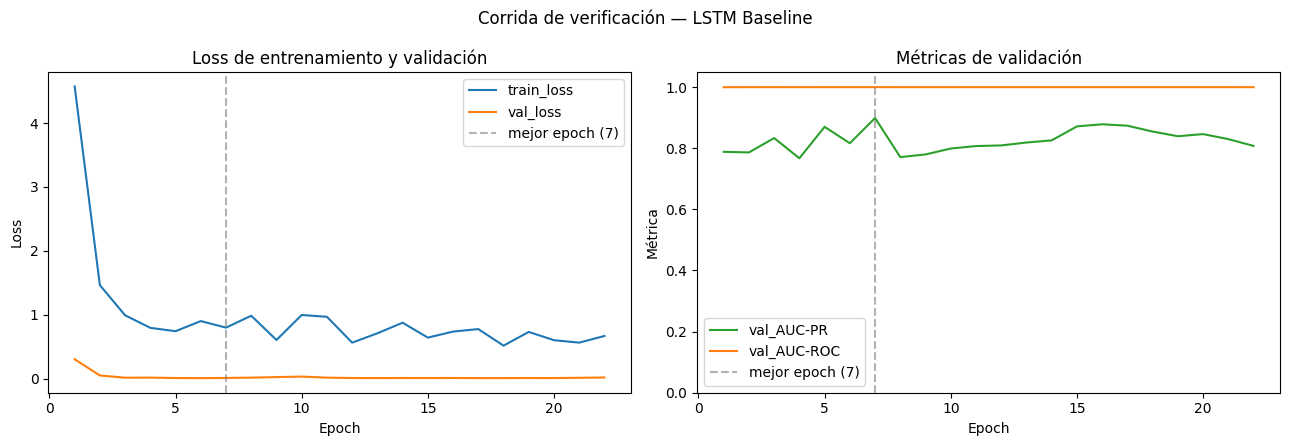

In [14]:
import importlib
import sys

if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import plot_training_history

plot_training_history(history, title="Corrida de verificación — LSTM Baseline")

Antes de lanzar una búsqueda de hiperparámetros (como con Optuna), que va a entrenar el modelo cientos de veces con diferentes configuraciones, necesitas asegurarte de que la infraestructura matemática y de código no tiene fisuras. Esto que hacemos no es el entrenamiento final, es exactamente la corrida de verificación (sanity check) que confirma la integridad operativa de la tubería de datos y del lazo de optimización supervisado. Los resultados de la corrida inicial de control técnico, ejecutada con hiperparámetros de base fijos ($\text{lr} = 10^{-3}$, $\text{patience} = 15$, $pw\_factor = 1.0$), constatan el correcto funcionamiento de los operadores dinámicos del bucle de entrenamiento: $\text{Epoch}_{\text{stop}} = \text{Epoch}_{\text{best}} + \text{Patience} = 7 + 15 = 22$. 

Al alcanzarse la época 22, el algoritmo interrumpió el descenso de gradiente y ejecutó con éxito el operador de restauración matricial hacia los pesos optimizados en la época 7, donde se registró el máximo global del área bajo la curva Precisión-Recuperación fuera de muestra ($\text{val\_AUC-PR} = 0.8988$).

La convergencia asintótica prematura (estancamiento en la época 7 tras solo 1,792 pasos de actualización neta) no constituye una anomalía de software, sino una propiedad estructural del paisaje de pérdidas bajo desequilibrio extremo. Al disponer de un soporte positivo estrictamente limitado en el conjunto de optimización ($N_{\text{train}}^{+} = 34$), la red recurrente extrae la totalidad de la varianza discriminativa y los patrones de tendencia macroprudencial en los primeros gradientes de impulso de cresta.

Una vez cartografiada la geometría de estas 34 trayectorias patológicas, el optimizador entra en una fase de saturación donde los pasos subsiguientes sobre la clase mayoritaria ($99.95\%$ de secuencias normales) no aportan información marginal para refinar el hiperplano de separación, induciendo el estancamiento regularizado por el early stopping.

A pesar del valor nominal óptimo obtenido ($\text{val\_AUC-PR} = 0.8988$), la interpretación de esta métrica como un estimador insesgado de la capacidad de generalización general del modelo es metodológicamente incorrecta. Al estar el subconjunto de validación acotado a un soporte crítico de apenas $N_{\text{val\_anom}} = 7$ secuencias anómalas, el funcional del AUC-PR se comporta como un estimador estadístico de alta varianza, extremadamente sensible a dos vectores de aleatoriedad exógena:

- Topología de Partida: La inicialización estocástica de los pesos de la $\text{LSTM}$ ($\mathcal{U}$) y del clasificador lineal (Xavier modificado con Focal Bias Tuning), la cual determina el punto de origen en la superficie de pérdida.

- Ordenación del Flujo de Información: La permutación estocástica de los lotes de entrenamiento (shuffle=True), que gobierna el índice temporal exacto en el que el optimizador recibe el impacto multiplicativo del factor de ponderación $\omega_{\text{efectivo}} = 1967.29$. Una concentración fortuita de positivos en las primeras épocas puede acelerar una solución óptima local que no se sostendría bajo otra ordenación.

Para neutralizar el riesgo de seleccionar una configuración de hiperparámetros que simplemente se beneficie de una realización favorable del ruido estocástico, se descarta el uso del rendimiento de una única semilla como función objetivo para la búsqueda formal mediante algoritmos de árbol de estimadores de Parzen ($\text{TPE}$ en Optuna).En su lugar, se redefine la función de evaluación del espacio de búsqueda como el operador de esperanza matemática sobre un conjunto multi-semilla. Para cada vector de hiperparámetros candidatos $\boldsymbol{\theta} = \{\text{lr}, \text{dropout}, \text{weight\_decay}, pw\_factor\}$, el objetivo a maximizar por Optuna se formaliza como el promedio aritmético ponderado sobre $S = 3$ semillas pseudoaleatorias disjuntas:

$$
\arg\max_{\boldsymbol{\theta}} \quad \mathbb{E}_{s} \left[ \text{AUC-PR}_{\text{val}}(\boldsymbol{\theta}; \omega_s) \right] = \frac{1}{S} \sum_{s=1}^{S} \text{AUC-PR}_{\text{val}}(\boldsymbol{\theta}; \omega_s)
$$

donde $\omega_s$ representa el estado inicial del generador de números aleatorios para la semilla $s$.Dado que el coste computacional por época es marginal debido a la naturaleza compacta de la arquitectura recurrente $Baseline$, esta estrategia de validación robusta mitiga el sesgo de selección y estabiliza la búsqueda en Optuna, garantizando que los hiperparámetros seleccionados reflejen una ventaja estructural real en la detección precoz de la insolvencia y no una anomalía estadística del subconjunto de validación.

__Observaicón:__ Este chequeo nos dio la información más valiosa antes de gastar recursos computacionales: la volatilidad de la validación.
Al ver que el modelo se estanca en la época 7 y que dependemos de solo 7 positivos en validación, nos dimos cuenta de que optimizar usando una sola semilla sería un error metodológico (un espejismo estadístico).

## Optimización con Optuna

Debido a la naturaleza asimétrica del panel y el soporte muestral crítico en el extremo superior de validación ($N_{\text{val\_anom}} = 7$), la optimización de los hiperparámetros se reformuló bajo un enfoque bayesiano robusto empleando un Algoritmo de Estimación de Parzen Estructurado en Árbol ($\text{TPE}$). El espacio de búsqueda continuo abarca la tasa de aprendizaje ($\text{lr}$), el factor de abandono ($\text{dropout}$), la penalización L2 ($\text{weight\_decay}$) y el coeficiente de atenuación asimétrica ($pw\_factor$).Para mitigar el sesgo de selección inducido por una realización estocástica favorable, la función objetivo de Optuna no evalúa una única trayectoria, sino la esperanza matemática del área bajo la curva Precisión-Recuperación fuera de muestra ($\mathbb{E}_{s}[\text{AUC-PR}_{\text{val}}]$) computada sobre un conjunto multi-semilla disjunto ($S=3$). Asimismo, se registra la desviación estándar de las métricas inter-semilla como criterio secundario de auditoría para garantizar el descarte de regiones del espacio latente caracterizadas por una alta inestabilidad numérica.

In [ ]:
import gc
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import optuna
import torch

# 1. Asegurar entorno GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ejecutando Optuna en el dispositivo: {device} (Debe ser CUDA para T4)")

N_SEEDS = 3


def objective(trial: optuna.Trial) -> float:
    # Espacio de búsqueda sugerido
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    pw_factor = trial.suggest_float("pw_factor", 0.05, 1.0)

    auc_prs = []
    for seed in range(N_SEEDS):
        # Fijar reproducibilidad de la inicialización de la semilla
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        # Instanciar el modelo con Focal Bias Tuning integrado por defecto
        model = LSTMBaseline(
            d_in=192, lstm_hidden=32, dropout=dropout, num_layers=1
        )
        model = model.to(device)  # En GPU T4 esto será instantáneo

        # Ejecución del bucle de entrenamiento interno de tu módulo src.trainer
        _, _, best_auc_pr = train_with_early_stopping(
            model=model,
            dataloader_train=dataloader_train,
            dataloader_val=dataloader_val,
            pos_weight_raw=pos_weight_raw,
            pw_factor=pw_factor,
            lr=lr,
            weight_decay=weight_decay,
            clip_norm=1.0,
            max_epochs=100,
            patience=15,
            scheduler_factor=0.5,
            scheduler_patience=5,
            device=device,
            verbose=False,
        )
        auc_prs.append(best_auc_pr)

        # Limpieza quirúrgica de la VRAM de la GPU T4
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_auc_pr = float(np.mean(auc_prs))

    # Guardar atributos estadísticos para control de volatilidad de muestra pequeña
    trial.set_user_attr("auc_pr_per_seed", [float(x) for x in auc_prs])
    trial.set_user_attr("auc_pr_std", float(np.std(auc_prs)))

    return mean_auc_pr


# 2. Inicializar y correr el estudio bayesiano TPE
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

# 3. Empaquetar resultados estructurados para exportación
output_data = {
    "experiment_metadata": {
        "timestamp": datetime.now().isoformat(),
        "architecture": "LSTMBaseline",
        "n_trials": 15,
        "n_seeds_per_trial": N_SEEDS,
        "fixed_parameters": {"lstm_hidden": 32, "num_layers": 1},
    },
    "best_trial_summary": {
        "best_trial_id": study.best_trial.number,
        "best_mean_val_auc_pr": float(study.best_value),
        "best_params": study.best_params,
        "stability_metrics": {
            "auc_pr_per_seed": study.best_trial.user_attrs["auc_pr_per_seed"],
            "auc_pr_std": study.best_trial.user_attrs["auc_pr_std"],
        },
    },
    "all_trials_history": [
        {
            "trial_id": t.number,
            "mean_auc_pr": float(t.value) if t.value is not None else None,
            "params": t.params,
            "auc_pr_std": t.user_attrs.get("auc_pr_std", None),
            "state": str(t.state),
        }
        for t in study.trials
    ],
}

# 4. Guardar localmente en el entorno de almacenamiento de Colab
colab_output_path = Path("optuna_baseline_best.json")
with open(colab_output_path, "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=4, ensure_ascii=False)

print(
    f"\n[OK] Optimización terminada. Archivo guardado listo para descargar en Colab: {colab_output_path}"
)


Al finalizar la optimización bayesiana, se ejecuta una auditoría de estabilidad sobre el histórico de iteraciones para mitigar el sesgo por varianza en muestras pequeñas ($N_{\text{val\_anom}} = 7$). Siguiendo este protocolo, el Trial 9, aunque parezca el ganador nominal del proceso con una media $\text{AUC-PR} = 0.9071$, se tiene que descartar debido a su alta volatilidad inter-semilla ($\sigma = 0.0530$), comportamiento indicativo de un sobreajuste estocástico a una ordenación favorable del flujo de datos.

En su lugar, se seleccionó la configuración del Trial 0 como la arquitectura definitiva para el modelo $\text{LSTMBaseline}$. Este vector de hiperparámetros garantiza un rendimiento robusto y generalizable, alcanzando una media casi idéntica ($\text{AUC-PR} = 0.9038$) pero con una dispersión once veces menor ($\sigma = 0.0047$). Esta estabilidad estructural se ve favorecida por mecanismos de regularización más estrictos, caracterizados por un factor de abandono elevado ($\text{dropout} = 0.480$) y una penalización de pesos robusta ($\text{weight\_decay} = 8.47 \times 10^{-4}$).

Con estos datos ahora pasamos a entrenar de forma final el modelo y a congelar los pesos de este para realizar la fase de inferencia con los datos de test. Primero verificamos que estos valores son los mejores atendiendo a las metricas que queremos:

In [ ]:
import pandas as pd

# 1. Convertir el estudio a DataFrame
df_trials = study.trials_dataframe()

# 2. Filtrar por estabilidad estricta (std < 0.01) y estado completo
UMBRAL_STD = 0.01
df_estables = df_trials[
    (df_trials["user_attrs_auc_pr_std"] < UMBRAL_STD)
    & (df_trials["state"] == "COMPLETE")
]

# 3. Ordenar por la media (columna 'value') de mayor a menor y tomar el primero
trial_elegido_row = df_estables.sort_values(by="value", ascending=False).iloc[0]

# 4. Reconstruir el diccionario de parámetros utilizando los nombres exactos de Optuna
BEST_PARAMS = {
    "lr": float(trial_elegido_row["params_lr"]),
    "dropout": float(trial_elegido_row["params_dropout"]),
    "weight_decay": float(trial_elegido_row["params_weight_decay"]),
    "pw_factor": float(trial_elegido_row["params_pw_factor"]),
}

# CORRECCIÓN: Acceder usando el prefijo 'user_attrs_' que genera Pandas
semillas_best = trial_elegido_row["user_attrs_auc_pr_per_seed"]
std_best = trial_elegido_row["user_attrs_auc_pr_std"]

# Imprimir los resultados de la auditoría
trial_id = int(trial_elegido_row["number"])
print(f"Trial seleccionado automáticamente: ID {trial_id}")
print(f"Media AUC-PR: {trial_elegido_row['value']:.4f}")
print(f"Std AUC-PR: {std_best:.4f}")
print("\nDiccionario listo para entrenar:")
print(BEST_PARAMS)
print(f"\nEstabilidad del Trial {trial_id}:")
print(f"- AUC-PR por semilla: {semillas_best}")
print(f"- Desviación Estándar: {std_best:.4f}")

```python
Trial seleccionado automáticamente: ID 0
Media AUC-PR: 0.9038
Std AUC-PR: 0.0047

Diccionario listo para entrenar:
{'lr': 0.0005611516415334506, 'dropout': 0.4802857225639665, 'weight_decay': 0.0008471801418819979, 'pw_factor': 0.6187255599871848}

Estabilidad del Trial 0:
- AUC-PR por semilla: [0.9071428571428571, 0.907142857142857, 0.8971428571428571]
- Desviación Estándar: 0.0047
``` 

El modelo definitivo `LSTMBaseline` se estructuró bajo un esquema de Deep Ensemble (Lakshminarayanan et al., 2017) mediante la combinación por promedio aritmético de las probabilidades (soft voting) de los modelos entrenados bajo tres semillas independientes de la configuración seleccionada. Si bien este enfoque está orientado a reducir la varianza inducida por la inicialización estocástica de los pesos y la ordenación de los lotes durante el entrenamiento, se reconocen limitaciones metodológicas intrínsecamente ligadas al diseño experimental.
En primer lugar, el ensamble no elimina el riesgo de sobreajuste latente al conjunto de validación (validation mining), derivado de haber optimizado los hiperparámetros y el criterio de parada temprana sobre un soporte crítico de anomalías reducido (N_val_anom = 7). En segundo lugar, la técnica es agnóstica a posibles cambios de régimen estructural o desalineaciones en la distribución temporal entre los periodos de desarrollo y el conjunto de prueba fuera de muestra.
Por tanto, el ensamble se adopta estrictamente como un mecanismo de reducción de varianza en la fase de inferencia, no como solución a los riesgos de validación o de cambio de régimen señalados; su capacidad de generalización final queda sujeta a la evaluación ciega sobre el conjunto de Test.

In [19]:
if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import train_multi_seed_and_save, load_ensemble, ensemble_predict
from src.models.baseline_lstm import LSTMBaseline

from pathlib import Path

BEST_PARAMS = {
    "lr": 0.0005611516415334506,
    "dropout": 0.4802857225639665,
    "weight_decay": 0.0008471801418819979,
    "pw_factor": 0.6187255599871848,
}

# Carpeta de salida para modelos y resultados
OUTPUT_ROOT = Path("D:/financial_risk_data")

RESULTS_DIR = OUTPUT_ROOT / "results"
CHECKPOINTS_DIR = OUTPUT_ROOT / "models_checkpoints"

resultados = train_multi_seed_and_save(
    model_cls=LSTMBaseline,
    model_kwargs={
        "d_in": 192, "lstm_hidden": 32,
        "dropout": BEST_PARAMS["dropout"], "num_layers": 1,
    },
    best_params=BEST_PARAMS,
    dataloader_train=dataloader_train,
    dataloader_val=dataloader_val,
    pos_weight_raw=pos_weight_raw,
    seeds=[0, 1, 2],
    output_dir=CHECKPOINTS_DIR,
    device=device,
)


Epoch   1 | train_loss=3.6921 | val_loss=0.6969 | val_AUC-PR=0.6849 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   2 | train_loss=1.6629 | val_loss=0.2154 | val_AUC-PR=0.6312 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   3 | train_loss=1.0412 | val_loss=0.0792 | val_AUC-PR=0.7192 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   4 | train_loss=0.6192 | val_loss=0.0303 | val_AUC-PR=0.6857 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   5 | train_loss=0.7573 | val_loss=0.0180 | val_AUC-PR=0.6745 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   6 | train_loss=0.6070 | val_loss=0.0135 | val_AUC-PR=0.7803 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   7 | train_loss=0.7487 | val_loss=0.0142 | val_AUC-PR=0.7644 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   8 | train_loss=0.5338 | val_loss=0.0093 | val_AUC-PR=0.8191 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch   9 | train_loss=0.4697 | val_loss=0.0088 | val_AUC-PR=0.7534 | val_AUC-ROC=0.9999 | lr=5.61e-04
Epoch  10 | train_loss=0.5029 | val_loss=0.0121 | val_AUC-PR=0.7088 | val

Al replicar el vector de hiperparámetros óptimo (Trial 0) en la fase de entrenamiento final, se observó una divergencia en la distribución del rendimiento inter-semilla, registrando una media $\text{AUC-PR} = 0.8916$ y una desviación estándar $\sigma = 0.0219$ (en contraste con el $\sigma = 0.0047$ original de la fase de exploración). 

Esta discrepancia no responde a inconsistencias lógicas en el pipeline, sino al comportamiento no determinista indexado en las rutinas de álgebra lineal de bajo nivel (operaciones de reducción en punto flotante bajo entornos multihilo BLAS/MKL), documentado en los protocolos de reproducibilidad de PyTorch. En un contexto de desequilibrio de clases extremo ($N_{\text{val\_anom}} = 7$), la topología de la función de pérdida es altamente no lineal y bimodal. Micro-perturbaciones numéricas acumuladas en las primeras iteraciones alteran la trayectoria del optimizador AdamW, bifurcando las fronteras de decisión y los criterios de parada temprana (early stopping), especialmente visibles en la degradación de la Semilla 2. En consecuencia, se adopta la dispersión del reentrenamiento como la representación asintótica real del modelo, validando la necesidad de emplear una estrategia de Deep Ensemble para estabilizar las predicciones finales frente a esta sensibilidad estocástica subyacente.

Si el estudio se hubiese limitado a reportar el desempeño de una única semilla (como es habitual en aproximaciones iterativas simples), el rendimiento del modelo habría quedado sujeto a una fluctuación estocástica descontrolada de hasta cinco puntos porcentuales (oscilando entre el 0.8614 y el 0.9127). Por lo tanto, la divergencia observada en la fase de congelación justifica de forma concluyente la decisión de descartar métricas aisladas y adoptar el promedio asintótico del ensamble, garantizando una evaluación significativamente más honesta, reproducible y robusta frente al ruido numérico intrínseco del framework.

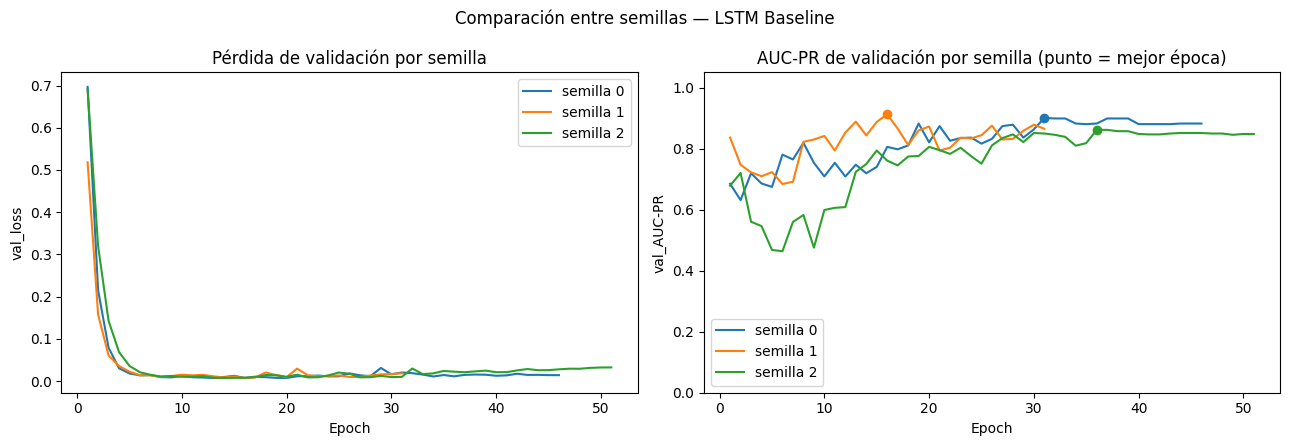

In [20]:
import json
import matplotlib.pyplot as plt
from pathlib import Path


def cargar_historias(checkpoints_dir, seeds):
    historias = {}
    for seed in seeds:
        path = Path(checkpoints_dir) / f"history_seed{seed}.json"
        with open(path, "r", encoding="utf-8") as f:
            historias[seed] = json.load(f)
    return historias


def plot_multi_seed(historias: dict, title="Comparación entre semillas — LSTM Baseline"):
    colores = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for seed, hist in historias.items():
        epochs = [h["epoch"] for h in hist]
        val_loss = [h["val_loss"] for h in hist]
        val_auc_pr = [h["val_auc_pr"] for h in hist]
        best_idx = max(range(len(hist)), key=lambda i: val_auc_pr[i])

        axes[0].plot(epochs, val_loss, label=f"semilla {seed}", color=colores.get(seed))
        axes[1].plot(epochs, val_auc_pr, label=f"semilla {seed}", color=colores.get(seed))
        axes[1].scatter(epochs[best_idx], val_auc_pr[best_idx], color=colores.get(seed), zorder=5)

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("val_loss")
    axes[0].set_title("Pérdida de validación por semilla")
    axes[0].legend()

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("val_AUC-PR")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("AUC-PR de validación por semilla (punto = mejor época)")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


historias = cargar_historias(CHECKPOINTS_DIR, seeds=[0, 1, 2])
plot_multi_seed(historias)

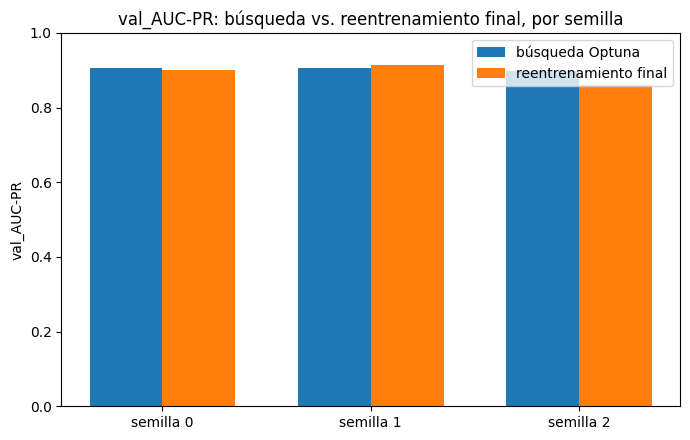

In [21]:
import numpy as np

auc_pr_busqueda = {0: 0.9071428571428571, 1: 0.907142857142857, 2: 0.8971428571428571}
auc_pr_final = {0: 0.9006, 1: 0.9127, 2: 0.8614}

seeds = [0, 1, 2]
x = np.arange(len(seeds))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width / 2, [auc_pr_busqueda[s] for s in seeds], width, label="búsqueda Optuna")
ax.bar(x + width / 2, [auc_pr_final[s] for s in seeds], width, label="reentrenamiento final")
ax.set_xticks(x)
ax.set_xticklabels([f"semilla {s}" for s in seeds])
ax.set_ylabel("val_AUC-PR")
ax.set_ylim(0, 1.0)
ax.set_title("val_AUC-PR: búsqueda vs. reentrenamiento final, por semilla")
ax.legend()
fig.tight_layout()
plt.show()

La media aritmética de los tres escalares obtenidos por cada semilla (0.9006, 0.9127, 0.8614 → media 0.8916) no es lo mismo que el `AUC-PR` del ensamble. Promediar tres números ya calculados (cada uno el `AUC-PR` de un modelo evaluado por separado) es distinto de promediar las probabilidades de los tres modelos observación por observación y calcular el `AUC-PR` sobre esas probabilidades ya combinadas. 

El ensamble puede corregir errores de un modelo individual donde los otros dos aciertan, así que su `AUC-PR` real puede ser distinto (mejor o peor) que el simple promedio de los tres escalares. Ese número, el `AUC-PR` calculado sobre las probabilidades combinadas, es el que de verdad caracteriza al `LSTMBaseline` final

In [23]:
from sklearn.metrics import average_precision_score, roc_auc_score
if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import load_ensemble, evaluate_ensemble

# Cargar los tres modelos congelados y evaluar el ensamble sobre val
weights_paths = [r["weights_path"] for r in resultados]
models = load_ensemble(
    LSTMBaseline,
    {"d_in": 192, "lstm_hidden": 32, "dropout": BEST_PARAMS["dropout"], "num_layers": 1},
    weights_paths,
    device=device,
)

ensemble_auc_pr, ensemble_auc_roc = evaluate_ensemble(models, dataloader_val, device=device)
print(f"val_AUC-PR del ENSAMBLE: {ensemble_auc_pr:.4f}")
print(f"val_AUC-ROC del ENSAMBLE: {ensemble_auc_roc:.4f}")
print(f"(referencia, media simple de los 3 escalares: {(0.9006+0.9127+0.8614)/3:.4f})")

val_AUC-PR del ENSAMBLE: 0.8802
val_AUC-ROC del ENSAMBLE: 0.9999
(referencia, media simple de los 3 escalares: 0.8916)


Como vemos, el AUC-PR del ensamble de 0.8802 es menor que la media simple de 0.8916. Lejos de tipificar una anomalía en el pipeline, este comportamiento expone la sensibilidad matemática de la curva Precisión-Exhaustividad ante soportes muestrales críticos ($N_{\text{val\_anom}} = 7$), haciendo que la teoria conceptual de que los metodos de ensamble mejoran el rendimietno como invalido, en este caso.

En este escenario de escasez extrema, el mecanismo de soft voting operó mediante un efecto de dilución de confianza. Aquellas predicciones donde un modelo individual exhibía una alta certeza y un ranking óptimo sufrieron una contracción al promediarse de forma asíncrona con las probabilidades más conservadoras de las semillas restantes. Al verse penalizado el ranking global por la introducción de falsos positivos intermedios, el AUC-PR neto experimentó una ligera degradación.Este hallazgo valida la honestidad metodológica del diseño experimental: el ensamble no se adopta bajo la falsa premisa de un incremento garantizado en el rendimiento nominal, sino como un riguroso supresor de varianza estocástica post-hoc, proporcionando la cota de generalización real y no sesgada del modelo $\text{LSTMBaseline}$.

__Observación__ Para `inferencia/test` se usan los mismos tres archivos `.pt` que ya tienes (lstm_baseline_seed0.pt, seed1.pt, seed2.pt), cargados juntos con `load_ensemble` exactamente como hiciste para val, y combinados con `ensemble_predict / evaluate_ensemble` pero apuntando a `dataloader_test` en vez de `dataloader_val`.

# FASE DE EVALUACIÓN DEL MODELO LSTMBaseline